# Image Processing with PyTorch

This notebook demonstrates how to process images in a dataset using geometric, color, and other transformations commonly used in data augmentation.

These techniques will later be applied for dynamic data augmentation.


### Refs

PyTorch Transforms: https://pytorch.org/vision/stable/transforms.html

Pytorch Illustration of Transforms: https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_illustrations.html



In [ ]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

### Settings

The notebook will use as example images from the Cats and Dogs dataset that can be downloaded from [Kaggle](https://www.kaggle.com/c/dogs-vs-cats/data)

In [3]:
data_dir = 'dogsVScats'

IMG_SIZE = 128
BATCH_SIZE = 8

In [4]:
from PIL import Image

img1 = Image.open(f'{data_dir}/cats/cat.3.jpg')
img2 = Image.open(f'{data_dir}/cats/cat.4.jpg')

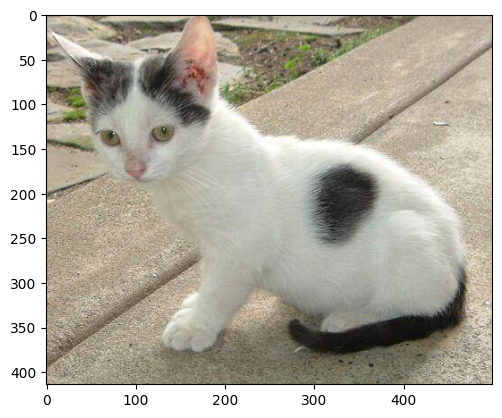

In [5]:
plt.imshow(img1)

# Defining data transformation

In V2, the *ToTensor* function is deprecated.

UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.


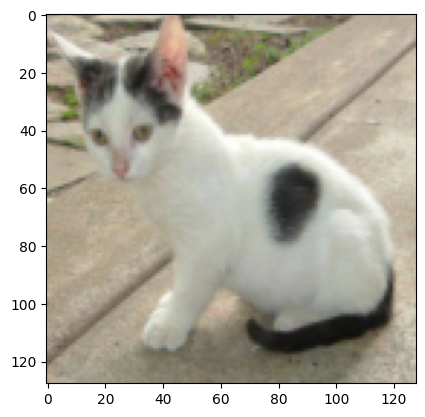

In [6]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE)), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)

plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

## Examples of geometric transformation

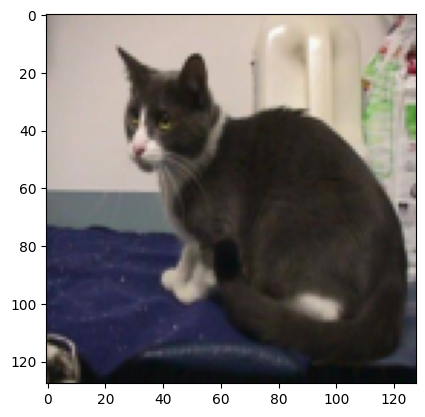

In [7]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.RandomHorizontalFlip(0.5), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img2)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

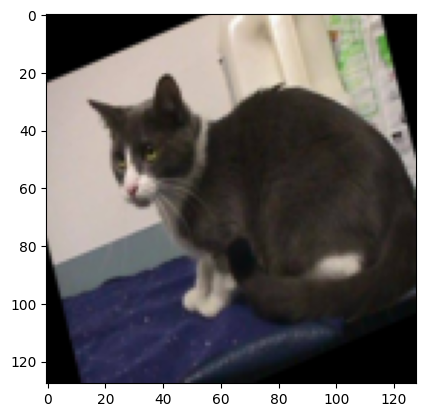

In [9]:
#Note: transform values are exaggerated to provide a clearer impression of the effect

transform = v2.Compose([ 
    v2.ToImage(), 
    v2.RandomRotation(45, v2.InterpolationMode.BILINEAR), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.RandomHorizontalFlip(0.5), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img2)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

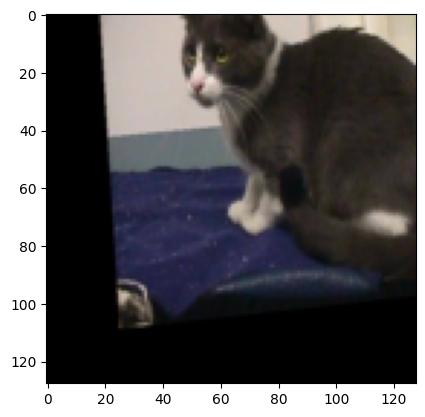

In [ ]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.RandomAffine(degrees=10, translate=(0.2, 0.2)), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img2)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

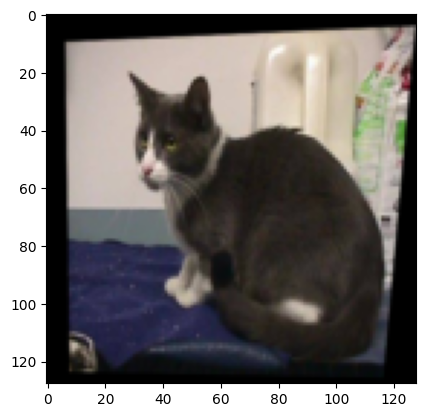

In [10]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.RandomPerspective(distortion_scale=0.2, p=1.0), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img2)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

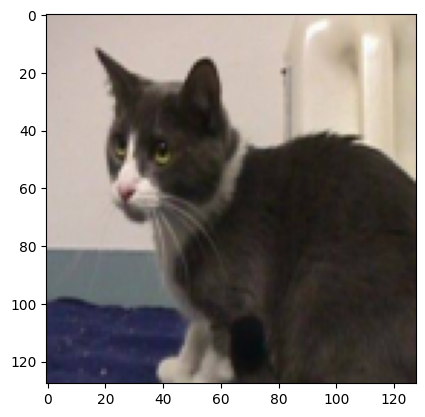

In [24]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE+50,IMG_SIZE+50), antialias=True), 
    v2.RandomCrop(size=(128, 128)),
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img2)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

## Examples of color transformation

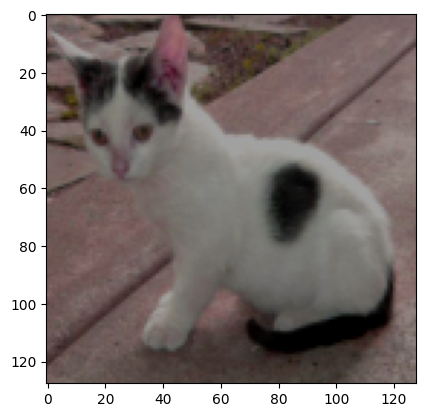

In [34]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ColorJitter(brightness = 0.5, contrast = 0.5,saturation = 0.2, hue = 0.2), 
    v2.ToDtype(torch.float32, scale=True)])

transf_img = transform(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

## Other transformations

### Random Erasing

Refs: *Random Erasing Data Augmentation* [PDF](https://arxiv.org/abs/1708.04896)

Random erasing simulates occlusions and missing information. The approach is to randomly selecting a rectangular region in an image and replacing its pixels with random values.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


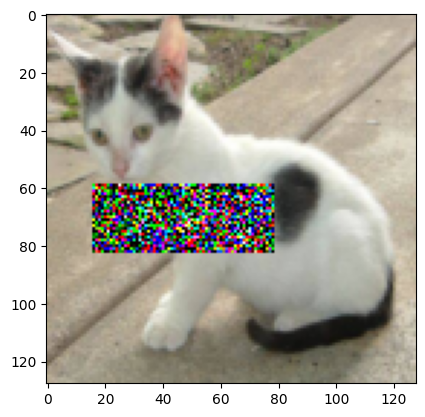

In [72]:
transformB = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(1, scale=(0.05,0.1), value='random')    
])

transf_img = transformB(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

### MixUp

Mixup is a data augmentation technique that generates new training examples by linearly interpolating pairs of images and their labels.

Note that this technique is applied to batches of images, and new labels are generated, which include multiple class probabilities. This transform should not be applied to the dataset transforms. 

Refs: *Mixup: Beyond Empirical Risk Minimization* [PDF](https://arxiv.org/abs/1710.09412)

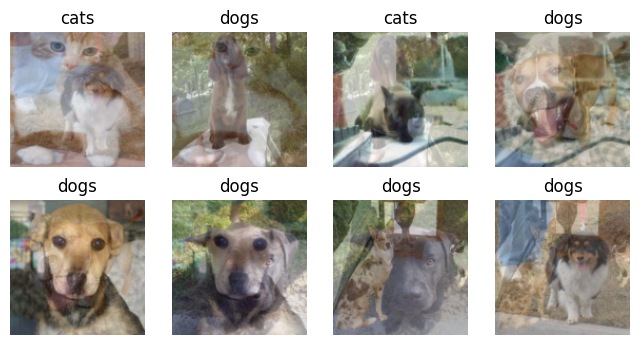

<Figure size 640x480 with 0 Axes>

Labels:  tensor([[0.6010, 0.3990],
        [0.3990, 0.6010],
        [0.6010, 0.3990],
        [0.3990, 0.6010],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.0000, 1.0000]])


In [ ]:
# the dataset has ony transforms that apply to individual images
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True)])

train_set = torchvision.datasets.ImageFolder(root=data_dir, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

# define the transform
mixup = v2.MixUp(num_classes=2)

# get a batch
imgs, labels = next(iter( train_loader))

# apply the transform to the batch
imgs2,labels2 = mixup(imgs,labels)

vcpi_util.show_images(2,4, imgs2, labels, train_set.classes)
print('Labels: ',labels2)

### Cut and Mix

CutMix cuts and pastes patches between images while adjusting labels accordingly. Similarly to MixUp, it also operates in batches.

Refs: *CutMix: Regularization Strategy to Train Strong Classifiers with Localizable Features* [PDF](https://arxiv.org/abs/1905.04899)



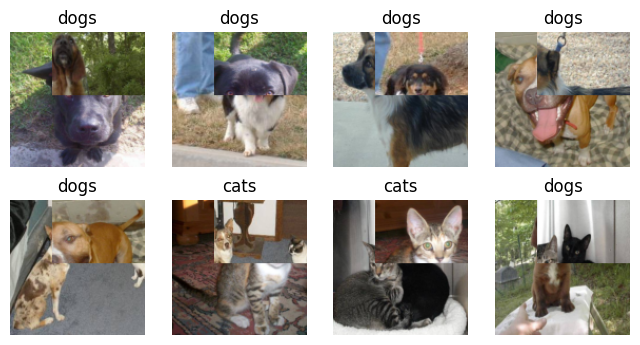

<Figure size 640x480 with 0 Axes>

tensor([[0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.6777, 0.3223],
        [1.0000, 0.0000],
        [0.3223, 0.6777]])


In [84]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True)])

train_set = torchvision.datasets.ImageFolder(root=data_dir, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

cutmix = v2.CutMix(num_classes=2)

imgs, labels = next(iter( train_loader))
imgs2,labels2 = cutmix(imgs,labels)
vcpi_util.show_images(2,4, imgs2, labels, train_set.classes)
print(labels2)

# Ways of combining transforms

Besides composing transforms, Pytorch allows other forms of combining transforms, such as:

- RandomApply - Apply randomly a list of transformations with a given probability.
- RandomChoice - Apply single transformation randomly picked from a list.
- RandomOrder - Apply a list of transformations in a random order.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


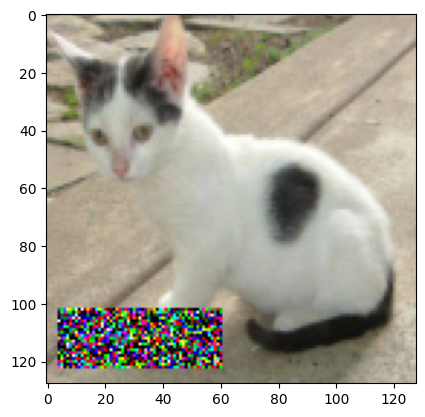

In [91]:
transformC = v2.Compose([
     v2.ToImage(), 
     v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
     v2.ToDtype(torch.float32, scale=True),
     v2.RandomApply([v2.RandomErasing(1, scale=(0.05,0.1), value='random')], 0.5)    
])

transf_img = transformC(img1)
plt.imshow(np.transpose(transf_img.numpy(),(1,2,0)))

*RandomChoice* can also be applied o batch transformers as CutMix and MixUp

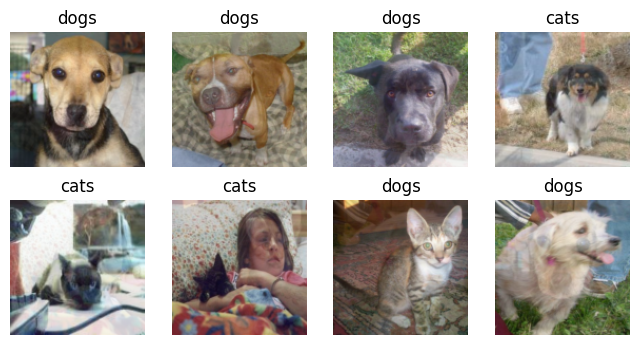

<Figure size 640x480 with 0 Axes>

tensor([[0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.2012, 0.7988],
        [1.0000, 0.0000],
        [1.0000, 0.0000],
        [0.7988, 0.2012],
        [0.0000, 1.0000]])


In [93]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.Resize((IMG_SIZE,IMG_SIZE), antialias=True), 
    v2.ToDtype(torch.float32, scale=True)])

train_set = torchvision.datasets.ImageFolder(root=data_dir, transform = transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

cutmix = v2.CutMix(num_classes=2)
mixup = v2.MixUp(num_classes=2)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup],[0.5,0.5])

imgs, labels = next(iter( train_loader))
imgs2,labels2 = mixup(imgs,labels)
vcpi_util.show_images(2,4, imgs2, labels, train_set.classes)
print(labels2)

# Concatenating two datasets with different transforms

Note that this effectively duplicates the number of samples in the training set.

In [18]:
train_loader_concat = torch.utils.data.DataLoader(
   torch.utils.data.ConcatDataset([
       torchvision.datasets.ImageFolder(root=data_dir, transform=transform),
       torchvision.datasets.ImageFolder(root=data_dir, transform=transformB)]), batch_size=16, shuffle= True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


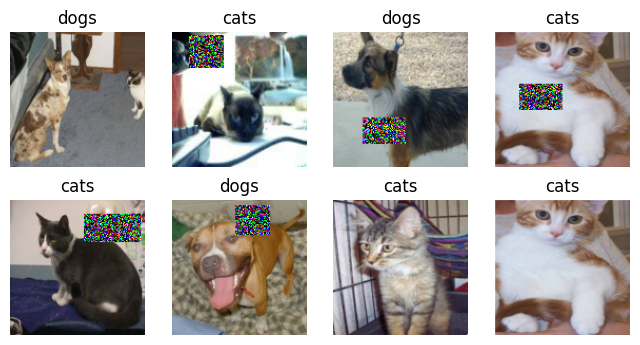

<Figure size 640x480 with 0 Axes>

In [19]:
imgs, labels = next(iter( train_loader_concat))
vcpi_util.show_images(2,4, imgs, labels, train_set.classes)